# mass spectra and the raw data

This is the first hands-on notebook of the spatial metabolomics primer, and it is the one that earns you the data. By the end you will know what a MALDI imaging experiment physically measures, what a MALDI measurement of a metabolit / lipid is and how it is named, and how a measured section becomes the table you compute on. Then you will build that table yourself, pulling two mouse brain sections straight from the public archive, stacking them into a pixels by ions matrix, attaching the brain anatomy to every pixel, and saving the result as the starting point for every notebook that follows.

what we build today, in order:

1. the physics: a laser, a speck of tissue, a mass spectrometer, one spectrum per pixel.
2. brain lipids: what a lipid is, why the brain is mostly lipid, the classes, and the name `PC 38:6`.
3. a spectrum is two arrays, and the formats that hold imaging data: METASPACE, zarr, parquet, pandas, AnnData.
4. the live pull: one section from METASPACE, results then images then a pixels by ions matrix.
5. a real mean MALDI spectrum, drawn with vertical sticks from measured numbers.
6. adducts: why one lipid shows up at several masses, and what sits in the feature table.
7. both sections, a tissue mask, and the common ions: the raw matrix.
8. the anatomy we hand you: attaching the Allen atlas coordinates and region to every pixel.
9. assemble one AnnData and save `data/derived/01_raw.h5ad`.
10. first maps: structure is already visible in a single raw ion.

## setup

We import the scientific Python stack and the small course package. `numpy` handles arrays, `pandas` handles tables, `matplotlib` draws, `anndata` is the container that will hold the imaging data, and `cajal_lipidomics` (imported as `cl`) is the set of helpers we wrote for this course. `set_style()` makes every figure come out clean and consistent, and we fix a seed so anything random is reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad

import cajal_lipidomics as cl
from cajal_lipidomics import plotting, annotation
from cajal_lipidomics.style import set_style, FS
set_style()

RNG = np.random.default_rng(0)
np.random.seed(0)

print("numpy", np.__version__)
print("cajal_lipidomics", cl.__version__)

numpy 1.26.4
cajal_lipidomics 0.0.1


## 1. what MALDI mass spectrometry imaging actually does

Picture a thin slice of frozen mouse brain, about ten micrometers thick, lying flat on a glass slide. We spray it with a fine layer of a small organic molecule called a matrix, here a compound named DHB. The matrix soaks in and co-crystallizes with the molecules already in the tissue. Now we fire a laser at one tiny spot. The matrix absorbs the laser energy, heats up in a flash, and bursts off the surface, carrying the tissue molecules with it into the gas phase. That matrix-assisted blast is the desorption, and it gives the technique its name: MALDI, Matrix-Assisted Laser Desorption/Ionization.

As the molecules leave the surface they gain or lose a charge, so they become ions. An electric field accelerates these ions into a mass spectrometer, which does one thing supremely well: it sorts ions by their mass-to-charge ratio, written m/z, and a detector counts how many ions arrive at each m/z. The output for that single laser spot is therefore a list, for every m/z value how much signal we saw. That list is a mass spectrum.

Now the imaging part. Instead of firing once, the instrument rasters the laser across the whole slice on a regular grid, here every 25 micrometers, recording a full spectrum at each grid point. Each grid point is a pixel. Stack the spectra back onto the grid and you have an image: at every pixel, the intensity of every measured molecule. The pixel size, 25 micrometers, is the spatial resolution, the finest spatial detail the experiment can resolve.

### a pixel is not a cell

This is the one caveat to carry through the whole course. A 25 micrometer pixel is far larger than a single neuron's cell body, and it contains a mixture of cell bodies, axons, dendrites, extracellular matrix, and glial projections. So a pixel reports the average lipid composition of a small patch of tissue, not the composition of one cell. When we later watch a lipid paint a brain region, we are seeing the bulk chemistry of that territory, not a single cell type. Keep this in mind every time you read a map.

check: in one sentence, say what the number stored at one pixel and one m/z represents physically. It is roughly how many ions of that mass-to-charge were desorbed from that 25 by 25 micrometer patch of tissue.

### the two sections we will use

Both brain sections in this course were acquired on an Orbitrap mass spectrometer in positive ion mode, at a mass resolving power of R = 240000 at m/z 200, a pixel size of 25 by 25 micrometers, over a mass range of m/z 400 to 1600, with DHB matrix. That resolving power is what lets the instrument separate two ions whose masses differ by a few thousandths of a Dalton, which we will need when we try to tell similar lipids apart. Because both sections share one protocol they are directly comparable, which is the whole point: one control brain and one pregnant brain, measured the same way, on the same coronal plane. The biological question waiting at the end of the course is whether pregnancy reshapes the lipid landscape of the brain.

## 2. brain lipids: what they are and how they are named

A lipid is a small biological molecule that barely dissolves in water but dissolves in oily solvents. The ones that matter most here build membranes. A membrane lipid has two parts: one or two long fatty chains of carbon and hydrogen, which hate water, and a small head group, which likes water. Pack millions of them tail-to-tail and the water-hating tails huddle inside while the water-loving heads face the watery world on both sides. That is a lipid bilayer, the two-molecule-thick sheet that wraps every cell and every organelle.

The brain cares about lipids more than almost any other organ. After you remove the water, about half of the brain's dry weight is lipid. Lipids build the membranes of neurons and glia, they form the synaptic vesicles that store neurotransmitters, and above all they build myelin, the fatty insulation that oligodendrocytes wrap around axons so electrical signals travel fast. White matter is white precisely because it is dense with myelin lipid. So when we map lipids across the brain, we map a chemistry the brain spends enormous resources to build and maintain.

### the classes we will meet

Membrane lipids come in families called classes, defined by their head group. The ones that dominate our data are:

- glycerophospholipids, built on a glycerol backbone with a phosphate and a head group:
  - PC, phosphatidylcholine: the most abundant membrane lipid, neutral head, workhorse of the outer membrane.
  - PE, phosphatidylethanolamine: smaller head, abundant, helps membranes curve.
  - PS, phosphatidylserine: negatively charged, enriched on the inner leaflet, a signal during cell death.
  - PI, phosphatidylinositol: negatively charged, a hub for cell signaling.
  - plus PA, PG, and the lyso forms LPC and LPE that carry a single chain.
- sphingolipids, built on a sphingosine backbone instead of glycerol, central to myelin:
  - SM, sphingomyelin: a phosphocholine head on a ceramide, abundant in myelin.
  - Cer, ceramide: the bare backbone, a signaling lipid and a building block.
  - HexCer, hexosylceramide: a ceramide with a sugar attached, a hallmark of myelin and a marker we return to again and again.

These few classes already account for most of the brain's membrane lipid mass.

### reading a lipid name like `PC 38:6`

Lipid shorthand packs a lot into a few characters. Read `PC 38:6` as three pieces:

- `PC` is the class, here phosphatidylcholine.
- `38` is the total number of carbon atoms summed across both fatty chains.
- `6` is the total number of carbon-carbon double bonds, also called unsaturations, summed across both chains.

So `PC 38:6` is a phosphatidylcholine whose two tails together carry 38 carbons and 6 double bonds. A sphingolipid name like `HexCer 42:2;O2` adds a `;O2` suffix recording two oxygens on the backbone, a detail of the ceramide hydroxylation. One subtlety: MALDI measures a mass, and a mass cannot tell apart an `18:0 / 20:6` arrangement from a `16:0 / 22:6` one, because both sum to `38:6`. So a single name is really a sum composition that may collapse several true molecules, called isomers, into one entry. We meet the consequence of that ambiguity in the next notebook, where we turn masses into names.

🔬 TASK: below is a tiny parser that turns a lipid name into its class, carbon count, and double-bond count with regular expressions. This is the recipe the Lipid Brain Atlas uses to color and group lipids. Read it, run it, then try a name of your own.

In [2]:
import re

def parse_lipid_name(name):
    '''Split a lipid shorthand into (class, carbons, double_bonds).

    'PC 38:6'        -> ('PC', 38, 6)
    'HexCer 42:2;O2' -> ('HexCer', 42, 2)
    The class is the text before the first space or parenthesis; the carbons are the
    number before the colon; the double bonds are the number right after the colon.
    '''
    lipid_class = re.split(r"[ (]", name)[0]          # text before first space/paren
    carbons = re.search(r"(\d+):", name)             # number before the colon
    doublebonds = re.search(r":(\d+)", name)         # number after the colon
    carbons = int(carbons.group(1)) if carbons else np.nan
    doublebonds = int(doublebonds.group(1)) if doublebonds else np.nan
    return lipid_class, carbons, doublebonds

for nm in ["PC 38:6", "HexCer 42:2;O2", "SM 36:1;O2", "PE 40:6"]:
    print(f"{nm:18s} -> {parse_lipid_name(nm)}")

PC 38:6            -> ('PC', 38, 6)
HexCer 42:2;O2     -> ('HexCer', 42, 2)
SM 36:1;O2         -> ('SM', 36, 1)
PE 40:6            -> ('PE', 40, 6)


💡 HINT: the helper `cl.data.lipid_properties` does this same parsing over a whole list of names at once and returns a tidy table indexed by lipid name, with the class, carbons, double bonds, oxygens, an ether flag, and a per-class color ready for plotting. We unroll the regex here so you can see there is no magic: a lipid name is just a class string and a few integers, and a regular expression pulls them out.

## 3. a spectrum is two aligned arrays, and the formats that hold the data

We said a spectrum is a list of m/z values and their intensities. Concretely it is two arrays of the same length, lined up index by index: `mz[0]` has intensity `intensity[0]`, `mz[1]` has intensity `intensity[1]`, and so on. To draw it we plant a vertical stick at each m/z whose height is its intensity. That stick picture is the canonical mass spectrum, and we will draw a real one shortly.

Before we pull any data, it helps to know the formats it travels in, because spatial metabolomics data is large and you will meet the same few containers again and again.

- METASPACE is the public web service that hosts the Lipid Brain Atlas raw data. It runs the annotation engine that decides which ions are present in a section, and it serves the per-ion images over the internet. We will talk to it directly in a moment.
- zarr is a format for very large array data: it splits an array into many small compressed chunks on disk so you can open the store without loading anything and then read only the chunks you need, for example one ion in one section. The full atlas keeps its imaging arrays as zarr because they are far too big to hold in memory at once. We will not parse zarr here, but the mental model matters: zarr is the on-disk warehouse for imaging arrays.
- a pandas DataFrame is a labeled table, one row per pixel and one column per measurement plus metadata, that you can filter, group, and join. Saved to disk it is often parquet, a columnar format that compresses each column separately, so it is small and fast to read when you only want a few columns.
- AnnData (annotated data) is the smart container we actually compute on. It wraps one central matrix `.X` (pixels by features) together with `.obs` (per-pixel metadata, aligned to the rows), `.var` (per-feature metadata, aligned to the columns), `.obsm` (per-pixel vectors like spatial coordinates), and `.uns` (a free-form bag). The power is that `.X`, `.obs`, and `.var` stay aligned automatically: subset the pixels and AnnData subsets `.X` and `.obs` together so they never fall out of step.

The rest of this notebook turns the raw METASPACE measurements into exactly one such AnnData and saves it.

## 4. the live pull, unrolled on one section

METASPACE is a web service, so the next cells talk to the internet. We work anonymously because the Lipid Brain Atlas project is public. The pull has three steps for a section, and we will name each one:

1. `ds.results(...)` returns the annotation table, one row per detected ion, indexed by chemical formula and adduct, with the measured m/z. This defines the features. Of course these API functions are useless to remember, just here for reference!
2. `ds.all_annotation_images(...)` returns one 2D intensity image per ion over the pixel grid. This defines the pixels and their values.
3. flatten and stack the images into a pixels by ions matrix.

Network downloads occasionally hiccup on an image transfer, so we wrap each call in a tiny retry loop that simply waits and tries again. We use the CoreMetabolome v3 database and keep annotations at a false discovery rate of 0.1, the published settings, and we ask for raw intensities (`scale_intensity=False`) and the monoisotopic peak only (`only_first_isotope=True`).

One knob there deserves a word, because we will lean on it. The false discovery rate, FDR, is the expected fraction of wrong calls among the annotations we keep. An FDR of 0.1 therefore means we accept a list in which at most about one ion in ten is expected to be a false match. METASPACE estimates it the way most discovery pipelines do: it also scores a batch of decoy formulas that cannot correspond to any real molecule, and it watches how often those decoys score as well as the real candidates. The rate at which decoys slip through, at a given score threshold, estimates the rate at which true annotations are wrong. Lowering the FDR buys a cleaner list at the cost of dropping borderline real ions, so 0.1 is the published compromise between precision and coverage.

In [3]:
from metaspace import SMInstance
import time

DB = ("CoreMetabolome", "v3")                          # the annotation database we trust
FDR = 0.1                                              # keep annotations at <=10% false discovery
PREGNANT_ID = "2024-07-14_14h24m11s"                   # Brain1_C2, our pregnant section
CONTROL_ID  = "2025-04-27_08h23m47s"                   # 217D, our control section


def with_retry(fn, tries=4, pause=3.0):
    '''Call fn(); on a transient network or PNG error, wait and try again.'''
    last = None
    for attempt in range(tries):
        try:
            return fn()
        except Exception as err:
            last = err
            print(f"  attempt {attempt + 1} failed ({type(err).__name__}); retrying...")
            time.sleep(pause)
    raise last


sm = SMInstance()                                      # anonymous: the project is public
ds = with_retry(lambda: sm.dataset(id=PREGNANT_ID))
print("dataset name:", ds.name)

dataset name: 20240712_MouseBrain_LipidAtlas_Pregnant_Brain1_C2_459x352_25um_Att30


The dataset name encodes everything: the date, that it is the LipidAtlas, that it is `Pregnant`, the brain and section `Brain1_C2`, and the image size `459x352` in pixels. Now the annotation table. Each row is one detected ion, indexed by formula and adduct, with the measured `mz`, a quality score `msm`, and the false discovery rate `fdr`.

In [4]:
res = with_retry(lambda: ds.results(database=DB, fdr=FDR))
print("annotated ions:", len(res))
print("columns:", list(res.columns))
res[["mz", "msm", "fdr"]].head(6)

annotated ions: 233
columns: ['ionFormula', 'ion', 'mz', 'msm', 'rhoSpatial', 'rhoSpectral', 'moc', 'fdr', 'offSample', 'isotopeImages', 'colocCoeff', 'moleculeNames', 'moleculeIds', 'intensity']


,,mz,msm,fdr
formula,adduct,,,
C40H80NO8P,+K,772.525313,0.972925,0.05
C43H76NO7P,+Na,772.525161,0.966316,0.05
C37H71O8P,+K,713.451814,0.963439,0.05
C39H73O8P,+K,739.467464,0.961964,0.05
C40H80NO8P,+Na,756.551376,0.957732,0.05
C42H82NO8P,+H,760.585082,0.956424,0.05


Now the images. `all_annotation_images` returns, for each annotated ion, a 2D intensity image over the pixel grid. We flatten each image to a vector and stack the vectors, giving a pixels by ions matrix. Averaging that matrix over pixels gives the mean intensity of each ion, which, paired with the m/z column, is the mean spectrum of the whole section.

In [5]:
img_sets = with_retry(lambda: ds.all_annotation_images(
    fdr=FDR, database=DB, only_first_isotope=True,
    scale_intensity=False, hotspot_clipping=False))
images = [np.asarray(s[0]) for s in img_sets]          # each is a (height, width) image
H, W = images[0].shape
X_one = np.stack([np.nan_to_num(im.flatten()) for im in images], axis=1).astype("float32")
print("one ion image is", (H, W), "pixels =", H * W, "flattened")
print("stacked matrix (pixels x ions):", X_one.shape)

mz_axis = res["mz"].to_numpy()
mean_spectrum = X_one.mean(axis=0)
print("mean spectrum has", len(mz_axis), "sticks, one per annotated ion")

  0%|                                        | 0/233 [00:00<?, ?it/s]

  0%|▏                                       | 1/233 [00:01<05:32,  1.43s/it]

  8%|███▎                                    | 19/233 [00:02<00:20, 10.45it/s]

 13%|█████▏                                  | 30/233 [00:02<00:12, 15.66it/s]

 16%|██████▎                                 | 37/233 [00:02<00:10, 19.15it/s]

...

 90%|███████████████████████████████████▉    | 209/233 [00:09<00:00, 33.96it/s]

 96%|██████████████████████████████████████▎ | 223/233 [00:09<00:00, 42.89it/s]

 99%|███████████████████████████████████████▍| 230/233 [00:09<00:00, 46.89it/s]

100%|████████████████████████████████████████| 233/233 [00:09<00:00, 23.85it/s]

one ion image is (352, 459) pixels = 161568 flattened
stacked matrix (pixels x ions): (161568, 233)
mean spectrum has 233 sticks, one per annotated ion


## 5. a real mean MALDI spectrum

We draw it with `cl.plotting.spectrum`, which plants a vertical stick at each m/z with height equal to its mean intensity. This is the average MALDI mass spectrum of a whole pregnant brain section, built entirely from measured numbers.

💡 HINT: open `src/cajal_lipidomics/plotting.py` and read `spectrum` before running it. It is a handful of lines around `ax.vlines`, the literal stick picture of a spectrum, so you can see there is no hidden processing between the numbers and the figure.

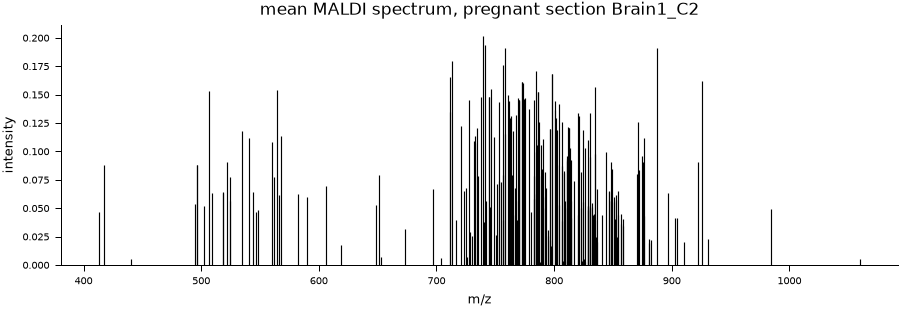

In [6]:
ax = plotting.spectrum(mz_axis, mean_spectrum,
                       title="mean MALDI spectrum, pregnant section Brain1_C2")
plt.show()

Read the figure. The horizontal axis is mass-to-charge. Each stick is one ion that METASPACE confidently annotated, and its height is how much of that ion the section holds on average. The tallest sticks crowd between roughly m/z 700 and 900, exactly where the abundant glycerophospholipids and sphingolipids of brain membranes sit. Notice how many sticks there are and how close together some stand. That crowding is the heart of the annotation problem: when two real lipids have nearly the same mass, their sticks nearly overlap, and only a very precise mass measurement can tell them apart. We tackle that in the next notebook.

### zoom into a crowded window

Let us zoom into a narrow mass window to see the crowding directly. We keep only the sticks between m/z 798 and 812 and replot, labeling each with its exact mass. Several ions live in this small band, separated by less than one Dalton.

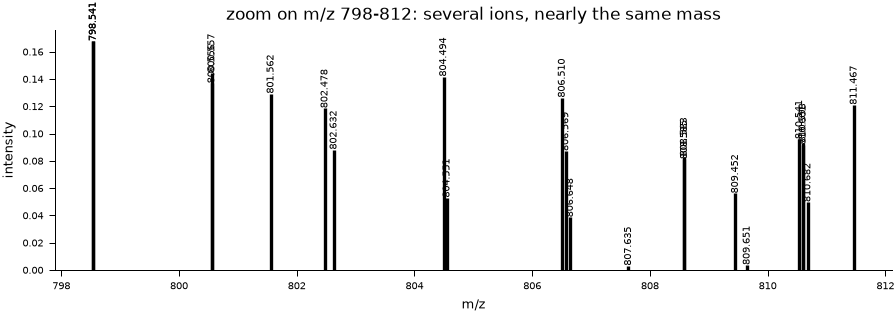

In [7]:
window = (mz_axis >= 798) & (mz_axis <= 812)
ax = plotting.spectrum(mz_axis[window], mean_spectrum[window],
                       title="zoom on m/z 798-812: several ions, nearly the same mass", lw=2.0)
for m, v in zip(mz_axis[window], mean_spectrum[window]):
    ax.annotate(f"{m:.3f}", (m, v), ha="center", va="bottom", fontsize=FS["xs"], rotation=90)
plt.show()

## 6. adducts: why one lipid shows up at several masses

Look at the index of the results table. Every feature is keyed by a chemical formula and an adduct, not by a lipid name. That is because a reference database lists the neutral mass of a lipid, the bare molecule, but the mass spectrometer only ever sees charged ions. A neutral lipid becomes charged by grabbing a small ion, and in positive mode it can grab a proton (`H+`), a sodium (`Na+`), a potassium (`K+`), or an ammonium (`NH4+`). Each adds its own little mass, so the same neutral lipid appears in the spectrum at several different m/z values, one per adduct.

In [8]:
# the positive-mode adduct masses (Da), from cl.annotation.ADDUCTS
for name, mass in annotation.ADDUCTS.items():
    print(f"adduct {name:4s} adds {mass:9.5f} Da")

print()
print("the feature index is (formula, adduct), and the same formula recurs with different adducts:")
print(res.index.to_frame(index=False).head(8).to_string(index=False))

adduct H+   adds   1.00728 Da
adduct Na+  adds  22.98977 Da
adduct K+   adds  38.96371 Da
adduct NH4+ adds  18.03382 Da

the feature index is (formula, adduct), and the same formula recurs with different adducts:
   formula adduct
C40H80NO8P     +K
C43H76NO7P    +Na
 C37H71O8P     +K
 C39H73O8P     +K
C40H80NO8P    +Na
C42H82NO8P     +H
C44H86NO8P     +H
C40H80NO8P     +H


So a single lipid scatters its signal across several sticks in the spectrum, and conversely two different lipids can land at nearly the same mass. Turning these formula-plus-adduct features into actual lipid names, within a parts-per-million mass window, is exactly the job of the next notebook. Here we keep the features as the instrument gives them and build the raw table.

## 7. both sections, a tissue mask, and the common ions

We just pulled one section. To build the course substrate we pull both, the control and the pregnant brain, and keep only the ions detected in both so the two are directly comparable on a shared feature set. We wrap the three pull steps into one function, with the same retry logic.

Two more pieces enter here. First, a tissue mask: each section has many grid points that fall on empty glass around the brain, and we do not want those. The mask is a boolean image, true where there is tissue, and we provide one per section under `data/masks/`. We keep only the pixels the mask marks as tissue. Second, the pixel coordinates: for every tissue pixel we record its `(x, y)` position on the grid, which we will need both to attach anatomy and to draw maps.

In [9]:
SECTIONS = {
    "control_217D": dict(
        ds_id=CONTROL_ID, sid=75.0, cond="naive",
        mask="../../data/masks/BrainAtlas/Control_Brains/female/"
             "20220416_MouseBrain_female_217D_447x332_Att30_25um/mask.npy"),
    "pregnant_Brain1_C2": dict(
        ds_id=PREGNANT_ID, sid=110.0, cond="pregnant",
        mask="../../data/masks/PREGNANT/"
             "20240712_MouseBrain_LipidAtlas_Pregnant_Brain1_C2_459x352_25um_Att30/mask.npy"),
}


def pull_section(ds_id):
    '''Pull one section into (image dict keyed by formula__adduct, feature table).'''
    ds = with_retry(lambda: sm.dataset(id=ds_id))
    res = with_retry(lambda: ds.results(database=DB, fdr=FDR))
    imgs = with_retry(lambda: ds.all_annotation_images(
        fdr=FDR, database=DB, only_first_isotope=True,
        scale_intensity=False, hotspot_clipping=False))
    keys = [f"{f}__{a}" for f, a in res.index]
    arrs = {k: np.asarray(s[0], np.float32) for k, s in zip(keys, imgs)}
    var = pd.DataFrame({"formula": [i[0] for i in res.index],
                        "adduct":  [i[1] for i in res.index],
                        "mz":      res["mz"].values}, index=keys)
    return arrs, var


per = {}
for name, cfg in SECTIONS.items():
    arrs, var = pull_section(cfg["ds_id"])
    per[name] = dict(arrs=arrs, var=var, mask=np.load(cfg["mask"]), cfg=cfg)
    print(f"{name}: {len(arrs)} ions, image {next(iter(arrs.values())).shape}, "
          f"{int(per[name]['mask'].sum())} tissue pixels")

common = sorted(set(per["control_217D"]["var"].index)
                & set(per["pregnant_Brain1_C2"]["var"].index))
print(f"\ncommon ions across both sections: {len(common)}")

  0%|                                        | 0/135 [00:00<?, ?it/s]

  1%|▎                                       | 1/135 [00:01<02:42,  1.21s/it]

 13%|█████                                   | 17/135 [00:01<00:07, 14.78it/s]

 22%|████████▉                               | 30/135 [00:01<00:04, 22.02it/s]

 25%|██████████                              | 34/135 [00:02<00:05, 17.79it/s]

...

 88%|███████████████████████████████████▎    | 206/233 [00:08<00:00, 38.07it/s]

 93%|█████████████████████████████████████▎  | 217/233 [00:08<00:00, 46.63it/s]

 98%|███████████████████████████████████████▎| 229/233 [00:09<00:00, 41.03it/s]

100%|████████████████████████████████████████| 233/233 [00:09<00:00, 25.27it/s]

pregnant_Brain1_C2: 233 ions, image (352, 459), 100258 tissue pixels

common ions across both sections: 104


Now assemble each section's raw matrix. For a section we take the tissue pixels from its mask with `np.nonzero`, read each common ion's intensity at exactly those pixels, and stack the ions into columns. The result is a pixels by ions matrix whose rows are the tissue pixels of that section and whose columns are the shared ions, in a fixed sorted order so the two sections line up column for column.

In [10]:
def build_block(P, common):
    '''Pixels-by-common-ions matrix for one section, plus a tidy per-pixel obs table.'''
    mask = P["mask"]
    ys, xs = np.nonzero(mask)                                   # tissue pixel coordinates
    X = np.stack([P["arrs"][k][ys, xs] for k in common], axis=1).astype(np.float32)
    obs = pd.DataFrame({"SectionID": P["cfg"]["sid"], "Condition": P["cfg"]["cond"],
                        "x": xs.astype(int), "y": ys.astype(int)})
    return X, obs


blocks = {name: build_block(P, common) for name, P in per.items()}
for name, (X, obs) in blocks.items():
    print(f"{name}: matrix {X.shape}, intensity range {X.min():.3f}..{X.max():.3f}")

control_217D: matrix (88753, 104), intensity range 0.000..1.000
pregnant_Brain1_C2: matrix (100258, 104), intensity range 0.000..1.000


## 8. the anatomy we hand you: attaching the Allen atlas

Every pixel so far knows only its position on its own image grid. To do anatomy we need to know, for each pixel, where it sits in the standard mouse brain and which named region it falls in. Getting there is called registration: you warp the section onto a reference atlas, the Allen Common Coordinate Framework (CCF), so every pixel receives a triple of atlas coordinates `(xccf, yccf, zccf)` and the acronym of the Allen region it lands in.

Registration is its own craft. Tools like ABBA and STalign align a section to the atlas by matching the tissue silhouette and internal landmarks, and doing it well is a notebook of its own. In this course we teach registration as a concept and hand you its output, because it is infrastructure rather than the lipid science we are after. So the one thing we provide ready-made is a small table giving, for every tissue pixel of every section, its CCF coordinates and its Allen region. It was produced by registering each raw section's silhouette to the atlas, and you can think of it exactly as the file ABBA or STalign would write.

We load that provided table and join it onto each section's pixels by `(SectionID, x, y)`, so every pixel picks up its anatomy.

In [11]:
# the provided registration output: CCF coordinates + Allen region per tissue pixel
ccf = pd.read_parquet("../../data/provided/registration_ccf.parquet")
print("provided registration rows:", len(ccf))
print("columns:", list(ccf.columns))
ccf.head(4)

provided registration rows: 189011
columns: ['SectionID', 'x', 'y', 'xccf', 'yccf', 'zccf', 'acronym', 'allencolor']


,SectionID,x,y,xccf,yccf,zccf,acronym,allencolor
control_217D_0,75.0,198,31,6.520779,0.350877,4.905680,RSPagl1,#1aa698
control_217D_1,75.0,199,31,6.520779,0.350877,4.905680,RSPagl1,#1aa698
control_217D_2,75.0,200,31,6.520779,0.350877,4.905680,RSPagl1,#1aa698
control_217D_3,75.0,201,31,6.520779,0.355736,4.930807,RSPd1,#1aa698


In [12]:
def attach_ccf(obs, ccf):
    '''Join the provided CCF coordinates + Allen region onto a section's pixels.'''
    key = ["SectionID", "x", "y"]
    merged = obs.merge(ccf, on=key, how="left", validate="one_to_one")
    assert merged["acronym"].notna().all(), "every tissue pixel must receive anatomy"
    return merged


obs_blocks = {name: attach_ccf(obs, ccf) for name, (X, obs) in blocks.items()}
ex = obs_blocks["control_217D"]
print("a few control pixels with anatomy attached:")
ex[["SectionID", "x", "y", "xccf", "yccf", "zccf", "acronym"]].head(5)

a few control pixels with anatomy attached:


,SectionID,x,y,xccf,yccf,zccf,acronym
0,75.0,198,31,6.520779,0.350877,4.905680,RSPagl1
1,75.0,199,31,6.520779,0.350877,4.905680,RSPagl1
2,75.0,200,31,6.520779,0.350877,4.905680,RSPagl1
3,75.0,201,31,6.520779,0.355736,4.930807,RSPd1
4,75.0,195,32,6.520779,0.367835,4.831537,RSPagl1


The join attaches four anatomy facts to every pixel: the three CCF coordinates that place it in the standard brain, and the `acronym` naming the Allen region it falls in. The `allencolor` column carries the atlas's official color for that region, which is handy for plotting anatomy later. With this in place, every pixel knows both its chemistry (the ion intensities) and its location in the brain.

## 9. assemble one AnnData and save stage one

Now we put it together. We stack the two sections' matrices into one `.X`, concatenate their per-pixel tables into `.obs`, and attach the per-ion table (formula, adduct, mz) as `.var`. That single AnnData is the raw substrate of the whole course, and we save it as `data/derived/01_raw.h5ad`.

In [13]:
X_all = np.vstack([blocks[name][0] for name in SECTIONS])
obs_all = pd.concat([obs_blocks[name] for name in SECTIONS], ignore_index=True)
obs_all.index = [f"{name}_{i}" for name in SECTIONS
                 for i in range(len(obs_blocks[name]))]
obs_all["Condition"] = obs_all["Condition"].astype(str)

var = per["control_217D"]["var"].loc[common, ["formula", "adduct", "mz"]].copy()

raw = ad.AnnData(X=X_all, obs=obs_all, var=var)
raw.var_names = common
print(raw)

AnnData object with n_obs × n_vars = 189011 × 104
    obs: 'SectionID', 'Condition', 'x', 'y', 'xccf', 'yccf', 'zccf', 'acronym', 'allencolor'
    var: 'formula', 'adduct', 'mz'


In [14]:
import os
os.makedirs("../../data/derived", exist_ok=True)
raw.write_h5ad("../../data/derived/01_raw.h5ad")
print("saved data/derived/01_raw.h5ad")
print("pixels per condition:", raw.obs["Condition"].value_counts().to_dict())
print("distinct Allen regions:", raw.obs["acronym"].nunique())

saved data/derived/01_raw.h5ad
pixels per condition: {'pregnant': 100258, 'naive': 88753}
distinct Allen regions: 174


check: explain what each of `.X`, `.obs`, and `.var` holds for this object, and why subsetting to the pregnant pixels must change `.X` and `.obs` together but leave `.var` alone. `.var` is per-ion, and we keep all the ions when we drop pixels.

That file is the only thing the next notebook needs. It will load `01_raw.h5ad`, give the formula-plus-adduct features real lipid names, and save its own stage. The course is a chain of such files, each one the honest output of the step before.

## 10. first maps: structure is already visible in a single raw ion

Before we color pixels by any chemistry, let us look at what a pixel even is. Every pixel in `raw` carries two kinds of fact: a spatial position, its CCF coordinates `(zccf, -yccf)`, and an anatomical label, the Allen region it fell in. The registration table even handed us the atlas's own color for each region in `allencolor`. So we can place every pixel at its position and paint it with its region color, and the brain should draw itself: neighboring pixels share regions, regions form contiguous territories, and the two sections look like two real coronal slices.

We draw that with `cl.plotting.spatial_categorical`, which scatters pixels at their CCF coordinates and colors each by a stored hex color, here `allencolor`. This is the same canvas every lipid map will use, so internalize it now: these are pixels in a real section. The payoff is a sanity check you will apply to every map that follows. A lipid is a physical quantity of a physical place, so a real lipid map must be spatially coherent, smooth territories rather than random speckle. If a map ever looks like noise, suspect the data, not the brain.

💡 HINT: open `src/cajal_lipidomics/plotting.py` and read `spatial_categorical` (and `spatial_lipid` just below it) before running them. They are short: both scatter `obs["zccf"]` against `-obs["yccf"]`, one coloring by a stored hex column and the other by an intensity vector on the plasma colormap. Knowing exactly what a helper does is the difference between running code and understanding it, so make a habit of opening the `.py` for every function you call.

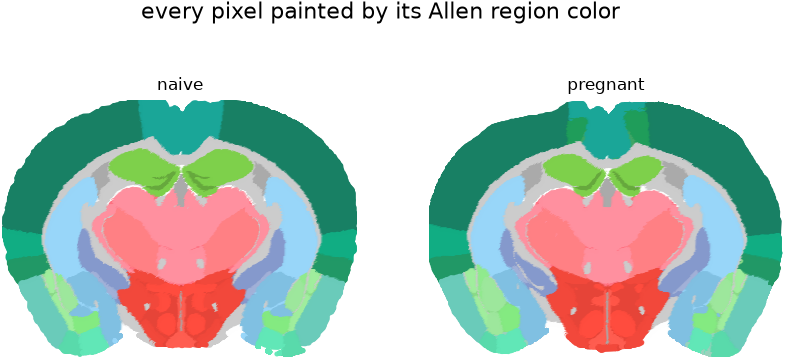

In [15]:
plotting.spatial_categorical(raw, color_key="allencolor")
plt.suptitle("every pixel painted by its Allen region color", y=1.02, fontsize=FS["l"])
plt.show()

There it is: two coronal sections, drawn entirely from registration labels, with the anatomy laid out in contiguous colored territories. No chemistry went into this picture, only each pixel's position and region. Now we keep the exact same canvas but swap the region color for a measured intensity, coloring each pixel by how much of one chosen ion it holds. The helper `cl.plotting.spatial_lipid` draws one panel per section on a shared color scale, so the two panels are directly comparable. We pass it an ion by its `formula__adduct` key rather than a lipid name, since names arrive next notebook.

We start with a sphingomyelin-range ion. Its formula carries two nitrogens, the signature of a sphingomyelin, the myelin lipid, so we expect it to trace the white matter, the fiber tracts that wire the brain together. Watch whether the bright pixels fall into coherent territories, exactly the spatial coherence the region map just taught us to expect.

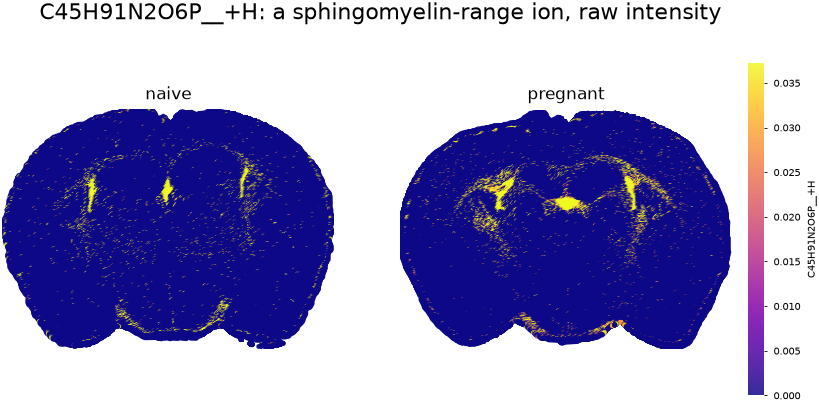

In [16]:
wm_ion = "C45H91N2O6P__+H"   # m/z 787.67, an SM-class ion (two nitrogens); named next notebook
plotting.spatial_lipid(raw, wm_ion)
plt.suptitle(f"{wm_ion}: a sphingomyelin-range ion, raw intensity", y=1.02, fontsize=FS["l"])
plt.show()

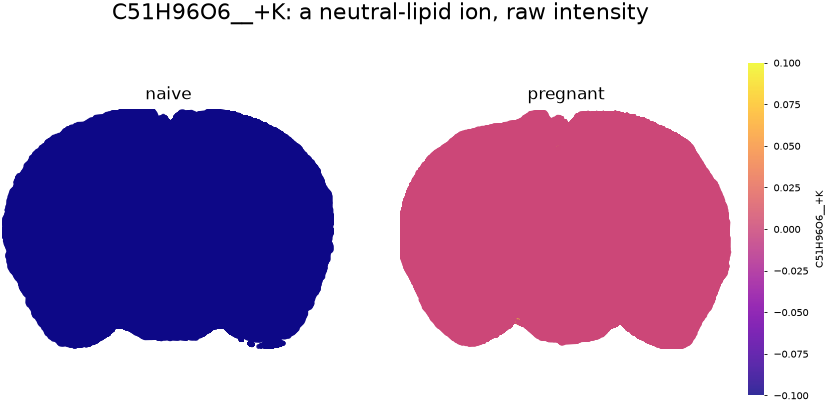

In [17]:
gray_ion = "C51H96O6__+K"    # m/z 843.68, a neutral lipid; named next notebook
plotting.spatial_lipid(raw, gray_ion)
plt.suptitle(f"{gray_ion}: a neutral-lipid ion, raw intensity", y=1.02, fontsize=FS["l"])
plt.show()

🔬 TASK: pick another ion from `raw.var_names` and map it. The cell below lists a few ions spanning the mass range to try. For each, decide whether it favors gray or white matter, and form a guess about which lipid class it might belong to.

In [18]:
# a few ions to explore: their formula hints at the class (N2 -> SM, no N/P -> neutral lipid)
for k in list(raw.var_names)[::12][:8]:
    mz = float(raw.var.loc[k, "mz"])
    print(f"{k:22s}  m/z {mz:8.3f}")

C23H46NO7P__+K          m/z  518.264
C39H73O8P__+K           m/z  739.467
C41H75O8P__+K           m/z  765.483
C42H80NO8P__+K          m/z  796.525
C43H75O8P__+K           m/z  789.483
C44H84NO8P__+K          m/z  824.557
C45H82NO8P__+K          m/z  834.541
C46H90NO10P__+H         m/z  848.638


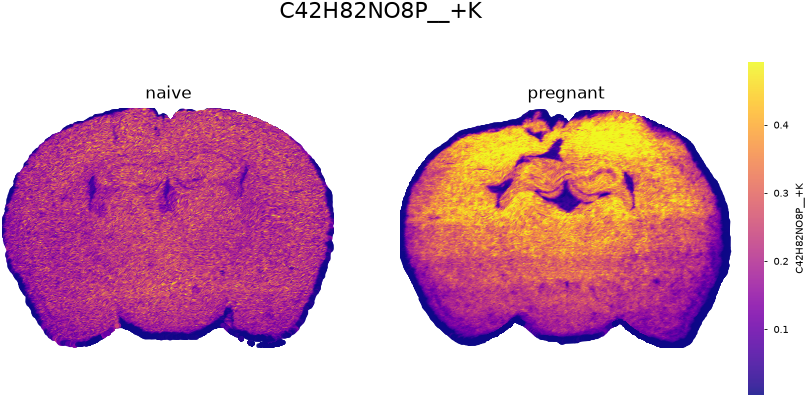

In [19]:
# your turn: replace the key and read the map
my_ion = "C42H82NO8P__+K"
plotting.spatial_lipid(raw, my_ion)
plt.suptitle(my_ion, y=1.02, fontsize=FS["l"])
plt.show()

One map shows one ion. To feel the diversity of spatial patterns, look at a dozen at once: each
ion paints a different territory, which is exactly why the lipidome can define anatomy. Here is a small gallery of a dozen ions chosen to be spatially structured yet mutually decorrelated — each paints a different territory, so together they show how varied the spatial patterns are (not a dozen look-alike white-matter maps).

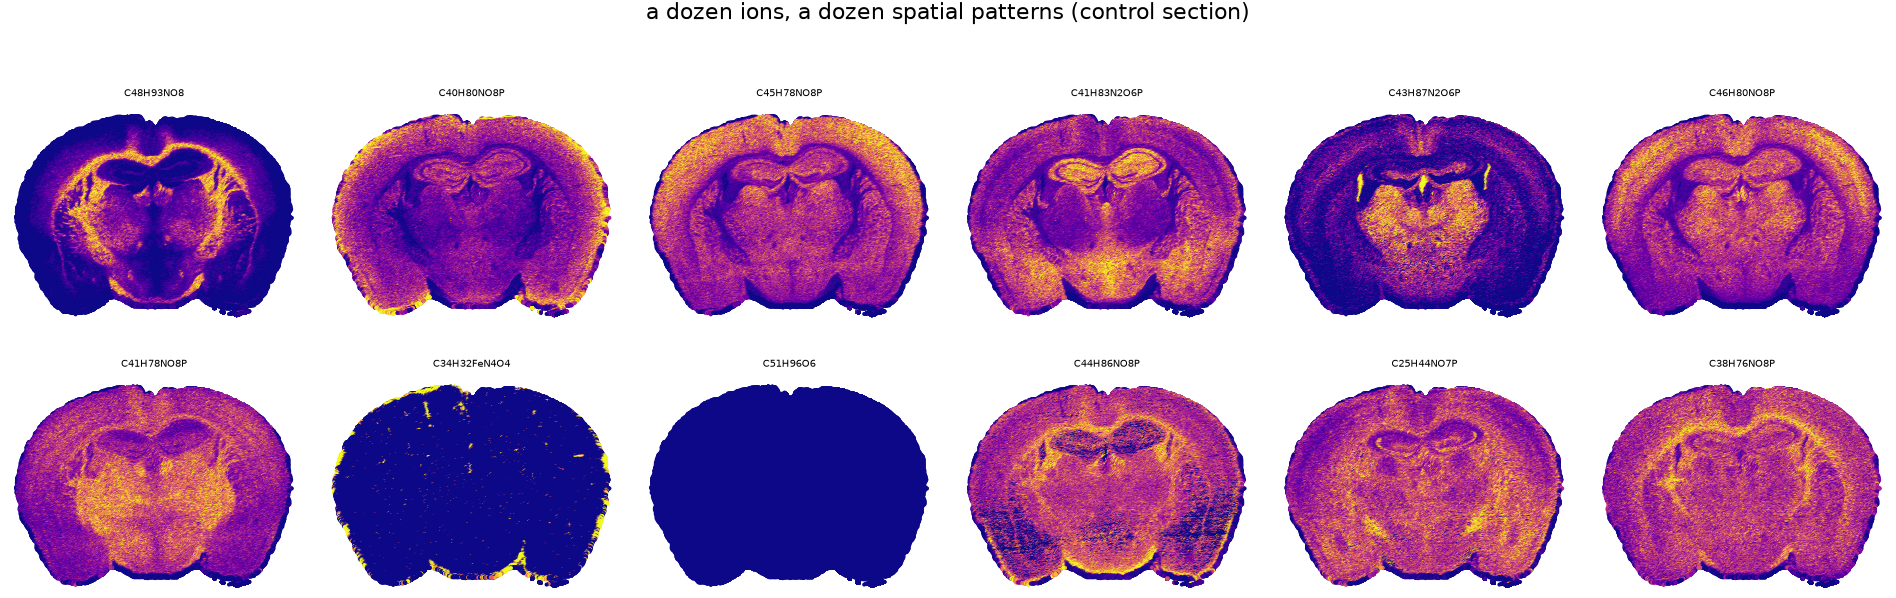

In [20]:
# a gallery: a dozen spatially structured BUT MUTUALLY DECORRELATED ions (each paints a
# different territory), one panel each, control section, per-panel 2-98% plasma scale.
# Chosen to span distinct anatomy -- not a dozen near-identical white-matter maps -- e.g. a
# heme/iron porphyrin (C34H32FeN4O4, vasculature) and a neutral lipid (C51H96O6) sit far from
# the myelin species. (Selection: high grid-ANOVA spatial structure + greedy low pairwise |r|.)
gallery = ['C48H93NO8__+K', 'C40H80NO8P__+Na', 'C45H78NO8P__+H', 'C41H83N2O6P__+K', 'C43H87N2O6P__+K', 'C46H80NO8P__+K', 'C41H78NO8P__+K', 'C34H32FeN4O4__+K', 'C51H96O6__+K', 'C44H86NO8P__+Na', 'C25H44NO7P__+K', 'C38H76NO8P__+K']
ctrl = (raw.obs.Condition == 'naive').to_numpy()
zc, yc = raw.obs.loc[ctrl, 'zccf'].to_numpy(), -raw.obs.loc[ctrl, 'yccf'].to_numpy()
fig, axes = plt.subplots(2, 6, figsize=(16, 5.4))
for ax, ion in zip(axes.ravel(), gallery):
    v = np.asarray(raw[:, ion].X).ravel()[ctrl]
    lo, hi = np.percentile(v, [2, 98])
    ax.scatter(zc, yc, c=v, cmap='plasma', s=2, vmin=lo, vmax=hi, rasterized=True)
    ax.set_aspect('equal'); ax.axis('off'); ax.set_title(ion.split('__')[0], fontsize=FS['xs'])
plt.suptitle('a dozen ions, a dozen spatial patterns (control section)', y=1.01, fontsize=FS['l'])
plt.tight_layout(); plt.show()

### three ions at once: where lipids co-localise

So far each map showed one ion. But the real point of spatial metabolomics is that different lipids occupy different territories, and we can see several at once by borrowing the trick a screen uses to make every color from three. We assign three ions to the red, green, and blue channels of a single image, each channel scaled to its own 2nd-to-98th percentile, and let the colors mix. Where two ions are both high a pixel turns yellow or magenta; where all three coincide it turns white; where only one is present it shows that pure channel. So the picture reads directly as a colocalization map: pure colors mark territories owned by one lipid, blends mark places two or three overlap.

We use `cl.plotting.rgb_overlay`, passing the three `formula__adduct` keys we just explored, the sphingomyelin-range ion, the neutral-lipid ion, and the one you mapped. Because it composites onto the raw pixel grid it takes the `(x, y)` image coordinates rather than CCF, so it reuses the per-section image we built in section 7.

💡 HINT: open `src/cajal_lipidomics/plotting.py` and read `rgb_overlay` before running it. Notice it does nothing exotic: it builds an empty `(H, W, 3)` image, drops each ion's percentile-clipped intensity into one channel at the pixels' `(y, x)`, and shows it. The colors you see are just three intensity maps stacked into the red, green, and blue slots.

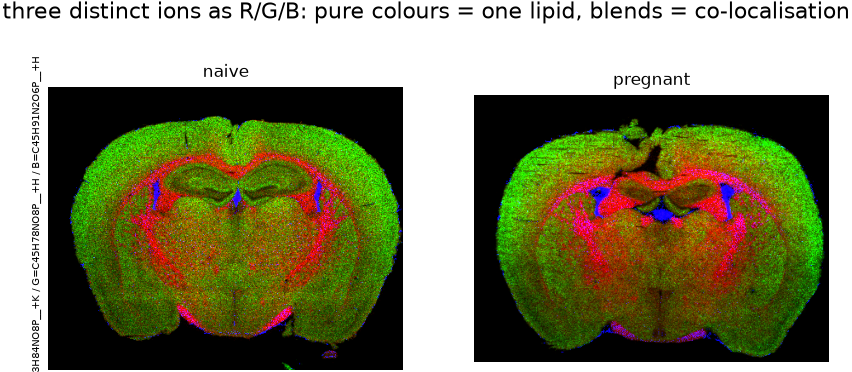

In [21]:
# three spatially DISTINCT, region-structured ions as R/G/B (chosen by how differently they
# distribute across Allen regions, so the channels separate rather than overlap)
trio = ['C43H84NO8P__+K', 'C45H78NO8P__+H', 'C45H91N2O6P__+H']
plotting.rgb_overlay(raw, trio)
plt.suptitle("three distinct ions as R/G/B: pure colours = one lipid, blends = co-localisation", y=1.02, fontsize=FS["l"])
plt.show()

## recap and what comes next

You now hold the foundations of the whole course, and you built the data with your own hands:

- MALDI imaging fires a laser at a 25 micrometer tissue spot, the spectrometer sorts the desorbed ions by mass-to-charge, and each spot becomes a pixel holding one spectrum. A pixel is a patch of tissue, not a cell.
- a spectrum is two aligned arrays, m/z and intensity, drawn as sticks. You plotted a real mean MALDI spectrum of a pregnant brain section.
- brain lipids are mostly membrane lipids, the brain is about half lipid by dry weight, and the name `PC 38:6` reads as class, total carbons, total double bonds, with isomers collapsed.
- the data lives as zarr on disk for huge arrays, as parquet for tables, and as AnnData in memory, the smart container with aligned `.X`, `.obs`, and `.var`.
- one lipid scatters across several m/z because of adducts (`H+`, `Na+`, `K+`, `NH4+`), and the raw features are keyed by formula and adduct, not by name.
- you pulled both sections from METASPACE, masked to tissue, kept the common ions, attached the provided Allen anatomy to every pixel, and saved `data/derived/01_raw.h5ad`.
- even raw and unnamed, the ions already separate gray matter from white matter, the central axis of brain lipid anatomy.

check before you move on: can you (1) state what one number in `.X` means physically, (2) parse `HexCer 42:2;O2` into class, carbons, double bonds, and oxygens, (3) explain why one lipid appears at several m/z values

what comes next. The next notebook loads `01_raw.h5ad` and gives every formula-plus-adduct feature a real lipid name, by matching its mass against a reference list within a parts-per-million window and handling the adducts and the isobaric ties head on. From there the chain continues: normalization, embedding, clustering into lipid territories, and finally the test of which lipids truly change between the control and the pregnant brain.